# M1-B1 — Réentraînement Pyrenex Crédit (template)

> Duplique ce notebook en `M1-B1_<prenom>_scoring.ipynb` et travaille dessus.

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [ ]:
%pip install matplotlib seaborn
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path('../data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

*Note ici les métriques de référence (F1 macro, ROC-AUC sur validation 2017), les features utilisées, l'architecture du modèle.*

Accuracy:   0.8479

F1 macro:   0.4989

ROC-AUC:    0.7324

Matrice de confusion:

| Réel \ Prédit | Fully Paid | Charged Off |
|---|---:|---:|
| Fully Paid | 2019 | 13 |
| Charged Off | 352 | 16 |

## 2. EDA du nouveau dataset

Au moins 3 visualisations + un paragraphe sur ce qui diffère du dataset 2017.

<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            24000 non-null  int64  
 1   term                 24000 non-null  str    
 2   int_rate             24000 non-null  float64
 3   installment          24000 non-null  float64
 4   grade                24000 non-null  str    
 5   emp_length           23047 non-null  str    
 6   home_ownership       24000 non-null  str    
 7   annual_inc           24000 non-null  int64  
 8   verification_status  24000 non-null  str    
 9   purpose              24000 non-null  str    
 10  dti                  24000 non-null  float64
 11  delinq_2yrs          24000 non-null  int64  
 12  fico_range_low       24000 non-null  int64  
 13  revol_util           23609 non-null  float64
 14  loan_status          24000 non-null  str    
dtypes: float64(4), int64(4), str(7)
memory usage: 2

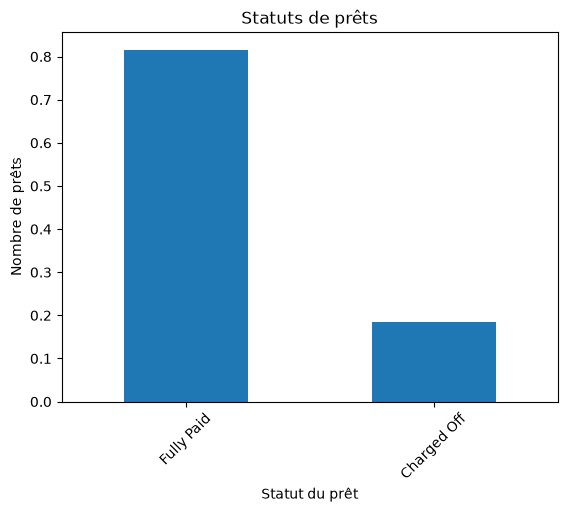

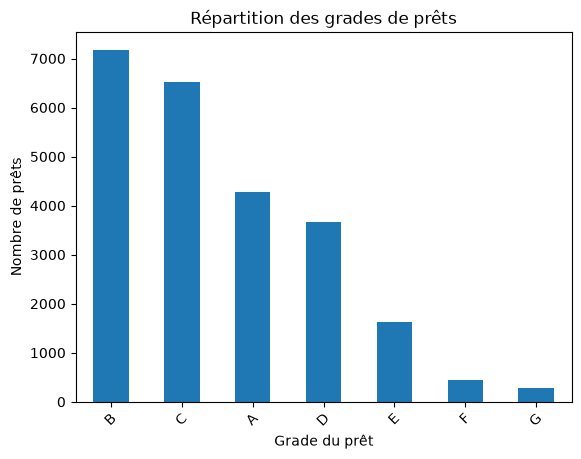

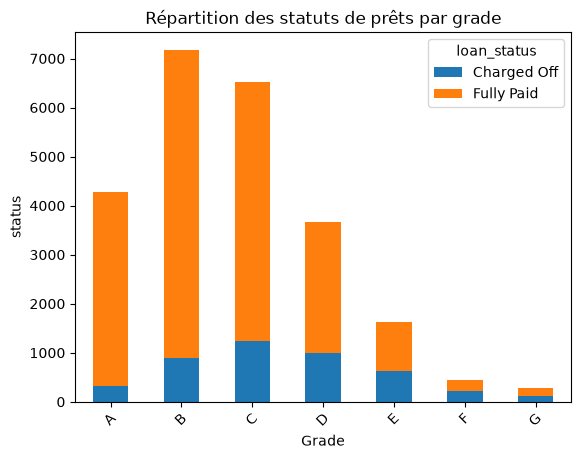

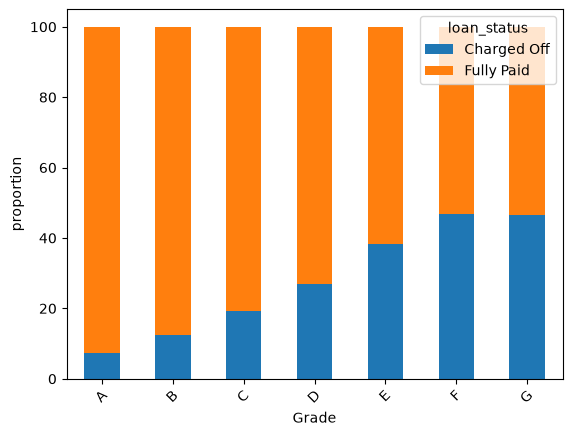

In [14]:
df = pd.read_csv(DATA_DIR / 'lending_club_train.csv')
df.shape, df.head(3)
df["loan_status"].value_counts(normalize=True).plot(kind="bar")
plt.title("Statuts de prêts")
plt.xlabel("Statut du prêt")
plt.ylabel("Nombre de prêts")
plt.xticks(rotation=45)
plt.show()

df["grade"].value_counts().plot(kind="bar")
plt.title("Répartition des grades de prêts")
plt.xlabel("Grade du prêt")
plt.ylabel("Nombre de prêts")
plt.xticks(rotation=45)
plt.show()

counts_by_grade_status = pd.crosstab(df["grade"], df["loan_status"])
counts_by_grade_status.plot(kind="bar", stacked=True)
plt.title("Répartition des statuts de prêts par grade")
plt.xlabel("Grade")
plt.ylabel("status")
plt.xticks(rotation=45)
plt.show()

proportions_by_grade_status = (pd.crosstab(df["grade"], df["loan_status"], normalize="index") * 100).round(2)
proportions_by_grade_status.plot(kind="bar", stacked=True)
plt.xlabel("Grade")
plt.ylabel("proportion")
plt.xticks(rotation=45)
plt.show()

home_status_correlation = (pd.crosstab(df["home_ownership"], df["loan_status"], normalize="index") * 100).round(2)
home_status_correlation.plot(kind="bar", stacked=True)
plt.xlabel("Home ownership")
plt.ylabel("proportion")
plt.xticks(rotation=45)
plt.show()

income_bins = [0, 30000, 50000, 75000, 100000, 150000, 250000, float("inf")]

income_labels = [
    "0-30k",
    "30k-50k",
    "50k-75k",
    "75k-100k",
    "100k-150k",
    "150k-250k",
    "250k+"
]

df["annual_inc_range"] = pd.cut(
    df["annual_inc"],
    bins=income_bins,
    labels=income_labels,
    right=False
)

income_status_table = (
    pd.crosstab(
        df["annual_inc_range"],
        df["loan_status"],
    )
)
income_status_table.plot(kind="bar", stacked=True)
plt.xlabel("Income range")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()



Par rapport au dataset de 2017, le dataset est plus volumineux, avec nettement plus de prêts "Fully Paid" que "Charged Off".

On peut également observer que les prêts avec un grade plus faible ont tendance à avoir un taux de défaut plus élevé, ce qui est cohérent avec l'idée que le grade reflète le risque du prêt.

De plus, la répartition des statuts de prêts ne varie pas en fonction du revenu annuel des emprunteurs ou du home ownership, ce qui suppose un dataset visant à évaluer indépendamment de ces facteurs (ou bien que ceux ci ne sont pas corrélés avec la capacité a rembourser le prêt).

## 3. Préparation et split

Split stratifié, `random_state=42`.

In [20]:
from sklearn.model_selection import train_test_split

target = "loan_status"
X = df.drop(columns=[target])
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Distribution complète :")
print(y.value_counts(normalize=True))

print("\nDistribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution validation :")
print(y_val.value_counts(normalize=True))

Distribution complète :
loan_status
Fully Paid     0.816125
Charged Off    0.183875
Name: proportion, dtype: float64

Distribution train :
loan_status
Fully Paid     0.816146
Charged Off    0.183854
Name: proportion, dtype: float64

Distribution validation :
loan_status
Fully Paid     0.816042
Charged Off    0.183958
Name: proportion, dtype: float64


## 4. Entraînement + benchmark

Au moins 2 jeux d'hyperparamètres. Trace chaque run dans `../experiments.md`.

## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# TODO : adapte aux noms de tes variables (X, y, et le modèle de la section 4)
scores = []
for seed in [0, 1, 42, 100, 2024]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    model = ...  # ré-instancie le même modèle qu'en section 4
    model.fit(X_tr, y_tr)
    f1 = f1_score(y_te, model.predict(X_te), average='macro')
    scores.append(f1)
    print(f"seed={seed:>4} → F1 macro = {f1:.3f}")

print(f"\nÉcart min-max : {max(scores) - min(scores):.3f}")

**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## 5. Évaluation sur holdout

F1 macro, F1 défaut, ROC-AUC, matrice de confusion, classification report.

## 6. Verdict

Synthèse à recopier dans `../verdict.md`.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.